**Objective:** Transform a Credit Scoring Model (Random Forest) into an economic decision-making tool.

1.  **Explain:** Use SHAP to understand which variables drive the risk score.
2.  **Calibrate:** Adjust the model's probabilities (trained on a balanced environment) to the real-world default rate (13.1%).
3.  **Optimize:** Simulate interest rate scenarios to find the maximum profitability point (*Sweet Spot*), considering both demand elasticity and risk elasticity.

In [ ]:
import joblib
import shap
import pandas as pd
import matplotlib.pyplot as plt
import copy
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [13]:
df = pd.read_csv('../data/loans_feature_engineered.csv')

In [14]:

X = df.drop(columns=["default_status"])
y = df["default_status"].astype(int)


## 1. Explainability Analysis (SHAP)

To understand the "whys" behind the score, we use **SHAP (SHapley Additive exPlanations)**.

Since the full Random Forest model is computationally expensive for calculating Shapley values, we perform a "surgery" to create a **lightweight version** (pruned to 50 estimators). This allows us to diagnose risk drivers on a representative sample without exhausting memory resources.

In [15]:
# 1. Load the Final Pipeline (Trained on the full dataset)
pipeline = joblib.load('../final_scoring_model.joblib')

# Access the model and preprocessor steps
# Using indices [-1] for the last step (model) and [0] for the first (preprocessor)
model = pipeline.steps[-1][1] 
preprocessor = pipeline.steps[0][1]

# 2. Create a shallow copy to preserve the original model
# This ensures we don't break the original pipeline if we need it later.
model_lite = copy.copy(model)

# 3. SURGERY: Prune estimators in memory
# We keep only the first 50 trees out of the original 500.
# This instantly reduces computational complexity by ~90%.
print(f"Original trees: {len(model.estimators_)}")

model_lite.estimators_ = model.estimators_[:50]
model_lite.n_estimators = 50

print(f"Trees for SHAP: {len(model_lite.estimators_)}")

# 4. Initialize SHAP with the lightweight model
explainer = shap.TreeExplainer(model_lite)

# NOTE: When calculating values, remember to pass transformed data:
# X_transformed = preprocessor.transform(X_sample)
# shap_values = explainer.shap_values(X_transformed)

Original trees: 500
Trees for SHAP: 50


In [17]:
# 4. Take a SAMPLE (The trick to prevent RAM explosion)
# 1000 rows are usually sufficient for very accurate SHAP plots.
# We use random_state to ensure the explanation is reproducible.
X_sample = X.sample(n=50, random_state=42)

# 5. Transform the sample (Prepare the data)
# Pass the sample through the pipeline preprocessor
X_sample_transformed = preprocessor.transform(X_sample)

# Retrieve column names (as seen before)
try:
    feature_names = preprocessor.get_feature_names_out()
except:
    feature_names = X_sample.columns

X_sample_ready = pd.DataFrame(X_sample_transformed, columns=feature_names)

shap_values = explainer.shap_values(X_sample_ready)

Taking a sample of 50 cases...
Transforming data with the preprocessor...
Data ready and feature names cleaned.
Original trees: 500
Model pruned to 50 trees for SHAP analysis.
Calculating SHAP values (this should be fast now)...
Generating Beeswarm Plot for Class 1 (Default)...


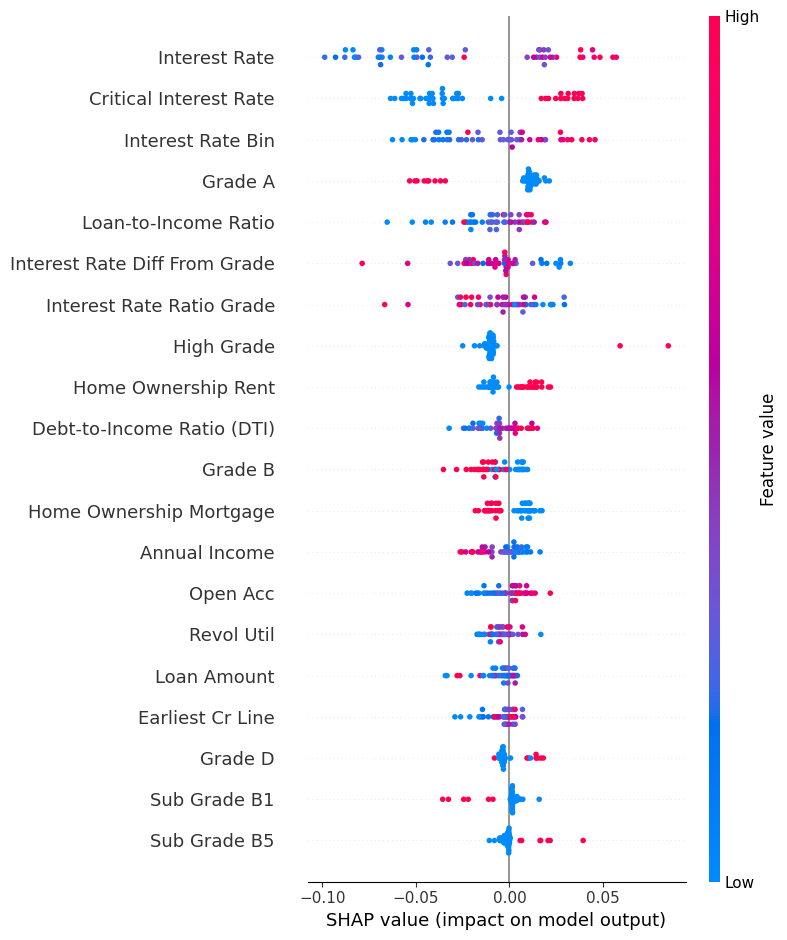

In [18]:
# --- HELPER FUNCTION FOR CLEAN FEATURE NAMES ---
def clean_column_name(ugly_name):
    """Transforms 'cat__grade_A' into 'Grade A'"""
    # 1. Remove pipeline technical prefixes
    clean_name = ugly_name.replace('remainder__', '').replace('cat__', '')
    
    # 2. Replace underscores with spaces
    clean_name = clean_name.replace('_', ' ')
    
    # 3. Convert to Title Case
    clean_name = clean_name.title()
    
    # Optional: Specific manual translations/adjustments
    replacements = {
        'Int Rate': 'Interest Rate',
        'Annual Inc': 'Annual Income',
        'Loan Amnt': 'Loan Amount',
        'Dti': 'Debt-to-Income Ratio (DTI)',
        'Loan To Income': 'Loan-to-Income Ratio'
    }
    
    for old, new in replacements.items():
        clean_name = clean_name.replace(old, new)
        
    return clean_name
# -------------------------------------------


# 1. LOAD AND PREPARE (Assuming 'X' is your original raw dataframe)
# Load the Final Giant Pipeline
pipeline = joblib.load('../final_scoring_model.joblib')

# Access the model (last step) and preprocessor (first step)
model_full = pipeline.steps[-1][1] 
preprocessor = pipeline.steps[0][1]

# Take a sample (using 50 for speed, you can increase to 200 if time permits)
N_SAMPLES = 50
print(f"Taking a sample of {N_SAMPLES} cases...")
X_sample_raw = X.sample(n=N_SAMPLES, random_state=42)

# 2. DATA PREPROCESSING (Transformation)
print("Transforming data with the preprocessor...")
X_sample_transformed = preprocessor.transform(X_sample_raw)

# Retrieve original raw feature names (handling sklearn versions)
try:
    feature_names_ugly = preprocessor.get_feature_names_out()
except:
    feature_names_ugly = X_sample_raw.columns

# --- APPLY NAME CLEANING ---
feature_names_nice = [clean_column_name(name) for name in feature_names_ugly]

# Create DataFrame ready for SHAP with clean names
X_sample_ready = pd.DataFrame(X_sample_transformed, columns=feature_names_nice)
print("Data ready and feature names cleaned.")


# 3. MODEL SURGERY (Vital for speed, especially with large models)
print(f"Original trees: {len(model_full.estimators_)}")

# Create a shallow copy to avoid modifying the original pipeline
model_lite = copy.copy(model_full)

# Prune to 50 trees so the calculation is fast
model_lite.estimators_ = model_full.estimators_[:50]
model_lite.n_estimators = 50

print(f"Model pruned to {model_lite.n_estimators} trees for SHAP analysis.")


# 4. CALCULATE SHAP VALUES
print("Calculating SHAP values (this should be fast now)...")
explainer = shap.TreeExplainer(model_lite)

# check_additivity=False is necessary when using the pruned model
shap_values_3d = explainer.shap_values(X_sample_ready, check_additivity=False)


# 5. PLOTTING (Using the correct slice for 3D array)
print("Generating Beeswarm Plot for Class 1 (Default)...")

# The output shape is (N_samples, N_features, 2_classes)
# We use [:, :, 1] to visualize the Positive Class (Default)
shap.summary_plot(shap_values_3d[:, :, 1], X_sample_ready)

In [ ]:
# --- 1. STRATEGIC SPLIT (10% Train / 90% Test) ---
# We use stratify=y to maintain the proportion of defaults in the small sample
X_train_mini, X_resto, y_train_mini, y_resto = train_test_split(
    X, y,
    train_size=0.10,     # Train with only 10%
    random_state=42,
    stratify=y
)

print(f"Training 'Mini' model with: {len(X_train_mini)} records.")
print(f"Reserving for Rate Study: {len(X_resto)} records (Out-of-Sample).")

# --- 2. DEFINE PIPELINE (IDENTICAL TO ORIGINAL) ---
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", ohe, cat_cols),
    ],
    remainder="passthrough"
)

# Same RF, same "safety nets" (min_samples_leaf=25)
rf_final = RandomForestClassifier(
    n_estimators=200,    # Lower estimators slightly for speed (500 -> 200)
    min_samples_split=10,
    min_samples_leaf=25,
    max_features="sqrt",
    max_depth=None,
    class_weight="balanced", # Keep class_weight="balanced" for good detection
    n_jobs=-1,
    random_state=42
)

pipe_mini = Pipeline(steps=[
    ("prep", preprocess),
    ("rf", rf_final),
])

# --- 3. FAST TRAINING ---
pipe_mini.fit(X_train_mini, y_train_mini)

print("Training completed!")

# --- 4. CONNECT WITH YOUR RATE STUDY ---
# Now, when running the simulation script (the plotting one), 
# you must use THIS model and THESE test data:

# pipeline = pipe_mini
# X_pool = X_resto.sample(n=2000, random_state=42)  <-- THIS IS THE KEY

# (Optional) Save the mini model for reuse
joblib.dump(pipe_mini, "mini_scoring_model_10percent.joblib")

Total de datos disponibles: 2258472
Entrenando modelo 'Mini' con: 225847 datos.
Reservando para el Estudio de Tasas: 2032625 datos (Out-of-Sample).
¡Entrenamiento completado!


['mini_scoring_model_10percent.joblib']

## 2. Bayesian Probability Calibration

**The Problem:** The model was trained on a balanced dataset (50% Default / 50% No-Default) to maximize its learning capability. However, this distorts the output probabilities: the model "believes" the world is far more dangerous than it actually is.

**The Solution:** We apply a **Prior Correction** based on the Real Default Rate observed in the portfolio (13.1%).

$$P(Real) \propto P(Model) \times \frac{Rate_{Real}}{Rate_{Model}}$$

This "squashes" the probabilities toward realistic values, allowing us to calculate expected returns that are not perpetually negative.

In [20]:
# --- 1. CONFIGURATION BASED ON EVIDENCE ---
# Hard data from your chart: 13.1% Real Default Rate
REAL_DEFAULT_RATE = 0.131 

# Business Parameters
LGD = 0.50             # Loss Given Default (Recovery Rate is 50%)
SENSITIVITY = 15.0     # Competition/Elasticity: High sensitivity means high churn if price is high
COL_RATE = 'int_rate'
IS_DECIMAL = True      # Flag to handle if rate is 0.15 or 15.0 in the raw data

# Load Model (Using the mini version for honest testing)
pipeline = joblib.load('../mini_scoring_model_10percent.joblib')

print("Configuration loaded. Model ready.")

Configuration loaded. Model ready.


In [21]:
# --- 2. CALIBRATION (PRIOR CORRECTION) ---
print("1. Calibrating model probabilities to real-world environment (13.1%)...")

# We use the 'Rest' dataset (Out-of-Sample) to measure model bias
X_pool = X_resto
probs_raw = pipeline.predict_proba(X_pool)[:, 1]

# Calculate bias
model_avg_prob = np.mean(probs_raw)
calibration_factor = REAL_DEFAULT_RATE / model_avg_prob

print(f"   > Predicted Average (Model): {model_avg_prob:.1%}")
print(f"   > Real Average (Target):     {REAL_DEFAULT_RATE:.1%}")
print(f"   > Correction Factor:         {calibration_factor:.4f}")
print("   (The model was exaggerating risk by a factor of {:.1f}x)".format(1/calibration_factor))

# Apply correction to the pool
probs_calibrated = np.minimum(probs_raw * calibration_factor, 1.0)

1. Calibrating model probabilities to real-world environment (13.1%)...
   > Predicted Average (Model): 40.3%
   > Real Average (Target):     13.1%
   > Correction Factor:         0.3254
   (The model was exaggerating risk by a factor of 3.1x)


## 3. Pricing Simulation & Hamiltonian Optimization

In this section, we stop treating the client as a static data point and model them as an **economic agent** reacting to our prices.

To find the optimal rate, we maximize the **Expected Return function**:

$$E[Profit] = P(Acceptance) \times \left[ \text{Expected Revenue} - \text{Expected Loss} \right]$$

Breaking down the physical terms:

1.  **Expected Revenue:** $(1 - P_{Default}) \times r$. What we earn if the client pays. $r$ is the Rate
2.  **Expected Loss:** $P_{Default} \times LGD$. What we lose if the client defaults (*Loss Given Default*).
3.  **Risk Dynamics (Stress):** The default probability $P_{Default}$ is not fixed; it increases if we "stress" the client with high rates (Reverse Causality).
4.  **Market Dynamics ($P_{Acceptance}$):** Modeled as an exponential decay (Boltzmann distribution). If our rate exceeds the market reference, the probability of the client accepting the loan drops rapidly.

$$P(Acceptance) = e^{-\beta \cdot (r_{Offered} - r_{Ref})}$$

Where $\beta$ represents the client's sensitivity to price (Elasticity).

In [22]:
# --- 3. PROFILE SELECTION ---
# Sort indices by the now CALIBRATED probability
sorted_indices = np.argsort(probs_calibrated)

# Select 3 representative profiles from the real distribution
idx_vip = sorted_indices[int(len(X_pool)*0.05)]  # Top 5% (Best quality)
idx_std = sorted_indices[int(len(X_pool)*0.50)]  # Median (Average client)
idx_sub = sorted_indices[int(len(X_pool)*0.85)]  # Risky (Bottom 15%)

profiles = X_pool.iloc[[idx_vip, idx_std, idx_sub]].copy()
names = ["VIP Client (Top 5%)", "Average Client", "Risky Client (Bottom 15%)"]
selected_base_probs = probs_calibrated[[idx_vip, idx_std, idx_sub]]

print("Profiles selected for simulation.")

Profiles selected for simulation.


In [23]:
# --- 4. OPTIMIZATION SIMULATION ---
test_rates = np.linspace(4, 25, 50) # Testing rates from 4% to 25%

results = {n: {'rates': [], 'profit': [], 'prob_def': [], 'prob_accept': []} for n in names}

for i, name in enumerate(names):
    client = profiles.iloc[[i]]
    base_prob = selected_base_probs[i]
    
    # Get Reference Rate (Historical rate or Market rate)
    try:
        val = client[COL_RATE].values[0]
        ref_rate = val if IS_DECIMAL else val / 100.0
        # print(f"Reference rate for {name}: {ref_rate:.4f}")
    except:
        ref_rate = 0.08 # Fallback: 8% if data is missing

    profits = []
    risks = []
    demands = []
    
    for rate_pct in test_rates:
        rate_dec = rate_pct / 100.0
        
        # A. RISK PHYSICS (Elasticity)
        # If we increase rate above reference, risk increases marginally (financial stress)
        delta = np.maximum(0, rate_dec - ref_rate)
        stress_factor = 1 + (1.2 * delta * 5) 
        final_default_prob = np.minimum(base_prob * stress_factor, 1.0)
        
        # B. MARKET PHYSICS (Demand)
        # If rate is too high vs reference, acceptance probability drops exponentially
        overprice = rate_dec - ref_rate
        accept_prob = np.exp(-SENSITIVITY * overprice) if overprice > 0 else 1.0
        
        # C. HAMILTONIAN (Expected Value)
        # E[R] = (Revenue * P_pay - Loss * P_default) * P_accept
        profit = (((1 - final_default_prob) * rate_dec) - (final_default_prob * LGD)) * accept_prob
        
        profits.append(profit)
        risks.append(final_default_prob)
        demands.append(accept_prob)
        
    results[name]['rates'] = test_rates
    results[name]['profit'] = profits
    results[name]['prob_def'] = risks
    results[name]['prob_accept'] = demands

print("Simulation completed.")

Simulation completed.


## 4. Results: Profitability Curves

The resulting curves demonstrate the **Trade-off between Risk and Competition**:

* **Left Zone (Low Rates):** Financial Loss. The rate fails to cover the base risk and operational costs.
* **The Peak (The Optimum):** The exact point where revenue is maximized before clients start rejecting the offer or risk skyrockets.
* **Right Zone (High Rates):** Profitability Drop. Although the unit margin is high, the volume of clients collapses (nobody accepts), and those who do are likely high-risk (*Adverse Selection*).

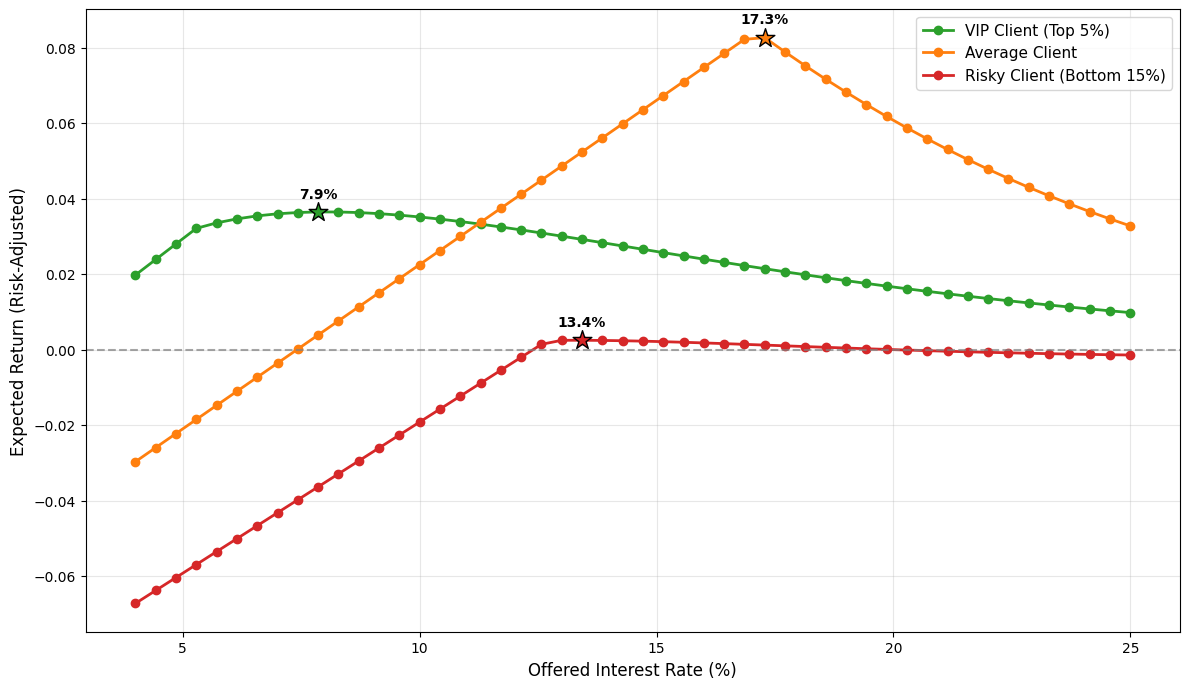

In [25]:
# --- 5. PLOTTING ---
# Single plot configuration
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#2ca02c', '#ff7f0e', '#d62728'] # Green, Orange, Red

# Plot: Realistic Profitability
for i, name in enumerate(names):
    ax.plot(results[name]['rates'], results[name]['profit'], '-o', label=name, color=colors[i], lw=2)
    
    # Mark Optimum Point
    y_values = np.array(results[name]['profit'])
    idx_max = np.argmax(y_values)
    val_max = y_values[idx_max]
    opt_rate = results[name]['rates'][idx_max]
    
    # Only mark if profitable
    if val_max > 0:
        ax.scatter(opt_rate, val_max, s=200, marker='*', c=colors[i], edgecolors='black', zorder=10)
        ax.annotate(f"{opt_rate:.1f}%", (opt_rate, val_max), 
                    xytext=(0, 10), textcoords='offset points', 
                    ha='center', fontweight='bold', fontsize=10)

#ax.set_title(f"Realistic Profitability (Calibrated to {REAL_DEFAULT_RATE:.1%})", fontsize=14)
ax.set_xlabel("Offered Interest Rate (%)", fontsize=12)
ax.set_ylabel("Expected Return (Risk-Adjusted)", fontsize=12)
ax.axhline(0, color='gray', linestyle='--', alpha=0.7)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()